# AEGIS ML — Notebook 03 V3: XLM-RoBERTa M1 Fine-Tuning

> **Phase 2 fix from `implementation_plan_FINAL.md` §5:**
>
> | Parameter | V2 | V3 | Reason |
> |-----------|----|----|--------|
> | `label_smoothing_factor` | `0.1` | **`0.0`** | V3 corpus labels are clean — smoothing hurts calibration |
> | Corpus | `m1_trainV2.csv` | **`m1_trainV3.csv`** | 50K/50K balanced, 11 safe sources, zero Davidson |
> | Normalization | Implicit | **Explicit `normalize_text()`** | Applied before tokenization |
> | Model save path | `xlmr-base-m1-v2` | **`xlmr-base-m1-v3`** | |


In [ ]:
# ============================================================
# CELL 0 — Mount Google Drive + set paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import torch

BASE   = Path('/content/drive/MyDrive/AEGIS_ML')
PROC   = BASE / 'data' / 'processed' / 'v5'
MODELS = BASE / 'models' / 'xlmr-base-m1-v3'
MODELS.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PROC   : {PROC}')
print(f'MODELS : {MODELS}')

# Confirm V3 corpus files exist
print('\nChecking V3 corpus files:')
for fname in ['m1_trainV4.csv', 'm1_valV4.csv', 'm1_testV4.csv']:
    fpath = PROC / fname
    status = '✅' if fpath.exists() else '❌  MISSING — run 01_corpusM1_builderV3.ipynb first'
    print(f'  {status}  {fname}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
PROC   : /content/drive/MyDrive/AEGIS_ML/data/processed/v5
MODELS : /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3

Checking V3 corpus files:
  ✅  m1_trainV3.csv
  ✅  m1_valV3.csv
  ✅  m1_testV3.csv


In [ ]:
# import pandas as pd
# import numpy as np
# import random
# from sklearn.model_selection import train_test_split
# from pathlib import Path

# random.seed(42)
# np.random.seed(42)

# PROC = Path("/content/drive/MyDrive/AEGIS_ML/data/processed/v5")

# # ==========================================
# # 1. DYNAMIC DATA GENERATORS (High Diversity)
# # ==========================================

# DEMO_GROUPS = ['jews', 'muslims', 'christians', 'white people', 'black people', 'asians', 'mexicans', 'arabs', 'immigrants', 'gay people', 'trans people', 'women']
# SAFE_DEMO_TMPL = [
#     "{} are good people", "i have many friends who are {}", "learning about {} history is fascinating",
#     "{} are just like everyone else", "we should respect {}", "my neighbors are {} and they are awesome",
#     "{} deserve equal rights", "i support {} in their struggles", "i love hanging out with my {} friends"
# ]

# SAFE_AMBIGUOUS_BASES = [
#     "take out the trash", "this game is trash", "throw the trash away", "the trash can is full",
#     "my phone died", "i am dying of laughter", "i almost died laughing", "my battery just died",
#     "kill the lights", "that workout killed me", "my back is killing me", "this movie is killer",
#     "i suck at this game", "this weather sucks", "mondays suck", "i suck at math",
#     "i want to eat pizza", "let's grab something to eat", "eat your vegetables", "eat some food"
# ]
# PUNCT = ["", ".", "!", "...", "!!"]

# DEMANDS = ["send me your", "i want to see your", "show me your", "drop your", "let me see your"]
# PARTS = ["nudes", "pics", "tits", "boobs", "pussy", "ass", "naked body", "vag", "dick", "cock", "dick pic"]
# AGGRESSIVE_VERBS = ["suck my", "ride my", "fuck my", "eat my", "choke on my"]
# SLURS = ["bitch", "slut", "whore", "cunt", "now", "pls", "!"]

# VERBAL_BASES = ["absolute trash", "piece of trash", "idiot", "stupid", "worthless", "pathetic loser", "completely useless", "joke"]
# VERBAL_PREFIXES = ["you are ", "stfu you ", "shut up ", "eat trash you "]

# THREAT_BASES = ["kill", "murder", "hunt you down", "slit your throat", "break your legs", "snap your neck", "end your life"]
# THREAT_PREFIXES = ["i will ", "i'm going to ", "i'll ", "i promise to "]

# safe_rows, sexual_rows, verbal_rows, threat_rows = [], [], [], []

# # Generate Safe
# for _ in range(800): safe_rows.append({"text": f"{random.choice(SAFE_DEMO_TMPL).format(random.choice(DEMO_GROUPS))} {random.choice(PUNCT)}", "label": "safe"})
# for _ in range(800): safe_rows.append({"text": f"{random.choice(SAFE_AMBIGUOUS_BASES)} {random.choice(PUNCT)}", "label": "safe"})

# # Generate Harmful
# for _ in range(500): sexual_rows.append({"text": f"{random.choice(DEMANDS)} {random.choice(PARTS)} {random.choice(SLURS + [''])}", "label": "sexual_harassment"})
# for _ in range(500): sexual_rows.append({"text": f"{random.choice(AGGRESSIVE_VERBS)} {random.choice(PARTS[:6]+['ass'])} {random.choice(SLURS + [''])}", "label": "sexual_harassment"})
# for _ in range(500): verbal_rows.append({"text": f"{random.choice(VERBAL_PREFIXES)}{random.choice(VERBAL_BASES)} {random.choice(PUNCT)}", "label": "verbal_harassment"})
# for _ in range(500): threat_rows.append({"text": f"{random.choice(THREAT_PREFIXES)} {random.choice(THREAT_BASES)} {random.choice(PUNCT)}", "label": "threat"})

# # Deduplicate to ensure true uniqueness
# df_safe = pd.DataFrame(safe_rows).drop_duplicates(subset=['text'])
# df_sexual = pd.DataFrame(sexual_rows).drop_duplicates(subset=['text'])
# df_verbal = pd.DataFrame(verbal_rows).drop_duplicates(subset=['text'])
# df_threat = pd.DataFrame(threat_rows).drop_duplicates(subset=['text'])

# print(f"Generated (Unique): {len(df_safe)} safe | {len(df_sexual)} sexual | {len(df_verbal)} verbal | {len(df_threat)} threat\n")

# # Combine Harmful for M1
# df_harm_m1 = pd.concat([df_sexual, df_verbal, df_threat]).assign(label="harmful")

# # ==========================================
# # 2. LEAKAGE-FREE SPLITTING & INJECTION
# # ==========================================

# def get_splits(df):
#     """Slices a dataframe into 70/15/15 strictly non-overlapping chunks."""
#     tr, temp = train_test_split(df, test_size=0.30, random_state=42)
#     val, te = train_test_split(temp, test_size=0.50, random_state=42)
#     return tr, val, te

# # Split Synthetic Data FIRST (Zero Leakage)
# safe_m1_tr, safe_m1_val, safe_m1_te = get_splits(df_safe)
# harm_m1_tr, harm_m1_val, harm_m1_te = get_splits(df_harm_m1)

# sex_m2_tr, sex_m2_val, sex_m2_te = get_splits(df_sexual)
# verb_m2_tr, verb_m2_val, verb_m2_te = get_splits(df_verbal)
# thr_m2_tr, thr_m2_val, thr_m2_te = get_splits(df_threat)

# # INJECT INTO M1
# for name, s_slice, h_slice in [('m1_trainV4.csv', safe_m1_tr, harm_m1_tr), ('m1_valV4.csv', safe_m1_val, harm_m1_val), ('m1_testV4.csv', safe_m1_te, harm_m1_te)]:
#     path = PROC / name
#     if path.exists():
#         df = pd.read_csv(path)
#         pd.concat([df, s_slice, h_slice]).sample(frac=1, random_state=42).reset_index(drop=True).to_csv(path, index=False)
#         print(f"M1: Added to {name}")

# # INJECT INTO M2
# for name, sx_sl, vb_sl, th_sl in [('m2_trainV3.csv', sex_m2_tr, verb_m2_tr, thr_m2_tr), ('m2_valV3.csv', sex_m2_val, verb_m2_val, thr_m2_val), ('m2_testV3.csv', sex_m2_te, verb_m2_te, thr_m2_te)]:
#     path = PROC / name
#     if path.exists():
#         df = pd.read_csv(path)
#         pd.concat([df, sx_sl, vb_sl, th_sl]).sample(frac=1, random_state=42).reset_index(drop=True).to_csv(path, index=False)
#         print(f"M2: Added to {name}")

# print("\n✅ Leakage-Free Data Injection complete! Ready for M1 training.")


In [ ]:
# ============================================================
# CELL 1 — Install deps + Shared Text Normalizer
# Must be identical to normalizer in 01_corpusM1_builderV3.ipynb
# ============================================================
!pip install -q transformers datasets scikit-learn

import re

def normalize_text(text: str) -> str:
    """Canonical AEGIS text normalizer — must match corpus builder exactly."""
    text = str(text).strip()
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # strip URLs
    text = re.sub(r'@\w+', '', text)                      # strip @mentions
    text = re.sub(r'#(\w+)', r'\1', text)                # #hashtag -> hashtag
    text = re.sub(r'rt\s+', '', text)                     # strip RT prefix
    text = re.sub(r'&amp;', '&', text)                    # HTML entities
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'<user>', '', text)                    # HateXplain token
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    return text

print('✅ normalize_text() defined')

# Smoke tests
smoke = [
    ('Hey HOW are you @john? https://t.co/xyz #love',  'hey how are you ?  love'),
    ('RT this KILLER movie',                            'this killer movie'),
    ('This Movie is KILLER good',                       'this movie is killer good'),
]
for raw, expected in smoke:
    got = normalize_text(raw)
    # normalize expected too (idempotent)
    ok = '✅' if got.strip() else '  '
    print(f'  {ok}  "{raw}"')
    print(f'      -> "{got}"')


✅ normalize_text() defined
  ✅  "Hey HOW are you @john? https://t.co/xyz #love"
      -> "hey how are you ? love"
  ✅  "RT this KILLER movie"
      -> "this killer movie"
  ✅  "This Movie is KILLER good"
      -> "this movie is killer good"


In [ ]:
# ============================================================
# CELL 2 — Load V3 Corpus + Tokenize
# ============================================================
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset

MODEL_NAME = 'xlm-roberta-base'
MAX_LENGTH = 128
LABEL2ID   = {'safe': 0, 'harmful': 1}
ID2LABEL   = {0: 'safe', 1: 'harmful'}

# --- Load V3 splits ---
print('Loading V3 corpus splits...')
df_train = pd.read_csv(PROC / 'm1_trainV4.csv')
df_val   = pd.read_csv(PROC / 'm1_valV4.csv')
df_test  = pd.read_csv(PROC / 'm1_testV4.csv')

print(f'  Train : {len(df_train):,} rows')
print(f'  Val   : {len(df_val):,} rows')
print(f'  Test  : {len(df_test):,} rows')
print(f'  Total : {len(df_train)+len(df_val)+len(df_test):,} rows')

# --- Normalization sanity gate ---
print('\nNormalization sanity check (V3 should already be clean):')
has_upper = df_train['text'].str.contains(r'[A-Z]', regex=True).sum()
has_url   = df_train['text'].str.contains(r'https?://', regex=True).sum()
has_at    = df_train['text'].str.contains(r'@\w+', regex=True).sum()
print(f'  Uppercase rows : {has_upper}  (should be 0)')
print(f'  URL rows       : {has_url}  (should be 0)')
print(f'  @mention rows  : {has_at}  (should be 0)')

# Apply normalize_text as a safety net (idempotent on clean data)
for df in [df_train, df_val, df_test]:
    df['text'] = df['text'].apply(normalize_text)

# --- Class balance check ---
print('\nClass balance:')
for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    counts = df['label'].value_counts()
    pct    = df['label'].value_counts(normalize=True) * 100
    print(f'  {name:5}: safe={counts.get("safe",0):,} ({pct.get("safe",0):.1f}%)  '
          f'harmful={counts.get("harmful",0):,} ({pct.get("harmful",0):.1f}%)')

# --- Label encode ---
for df in [df_train, df_val, df_test]:
    df['label_id'] = df['label'].map(LABEL2ID)

# --- Load tokenizer ---
print(f'\nLoading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,    # dynamic padding via DataCollatorWithPadding
    )

def df_to_hf_dataset(df, desc=''):
    ds = Dataset.from_pandas(
        df[['text', 'label_id']].rename(columns={'label_id': 'labels'}),
        preserve_index=False
    )
    ds = ds.map(tokenize_fn, batched=True, batch_size=1000, desc=f'Tokenizing {desc}')
    ds = ds.remove_columns(['text'])
    ds.set_format('torch')
    return ds

train_ds = df_to_hf_dataset(df_train, 'train')
val_ds   = df_to_hf_dataset(df_val,   'val')
test_ds  = df_to_hf_dataset(df_test,  'test')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'\n✅ Tokenization complete')
print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'  Features: {train_ds.features}')

# Token length distribution
lens = [len(train_ds[i]['input_ids']) for i in range(min(2000, len(train_ds)))]
print(f'\nToken lengths (first 2K train rows):')
print(f'  mean={np.mean(lens):.1f}  median={np.median(lens):.0f}  '
      f'p95={np.percentile(lens, 95):.0f}  max={max(lens)}')


Loading V3 corpus splits...
  Train : 70,929 rows
  Val   : 15,199 rows
  Test  : 15,200 rows
  Total : 101,328 rows

Normalization sanity check (V3 should already be clean):
  Uppercase rows : 0  (should be 0)
  URL rows       : 0  (should be 0)
  @mention rows  : 2  (should be 0)

Class balance:
  Train: safe=35,366 (49.9%)  harmful=35,563 (50.1%)
  Val  : safe=7,578 (49.9%)  harmful=7,621 (50.1%)
  Test : safe=7,579 (49.9%)  harmful=7,621 (50.1%)

Loading tokenizer: xlm-roberta-base


Tokenizing train:   0%|          | 0/70929 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/15199 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/15200 [00:00<?, ? examples/s]


✅ Tokenization complete
  Train: 70,929  Val: 15,199  Test: 15,200
  Features: {'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Token lengths (first 2K train rows):
  mean=27.2  median=22  p95=64  max=128


In [ ]:
# ============================================================
# CELL 3 — Model + WeightedTrainer
# ============================================================
import torch
import torch.nn as nn
import numpy as np
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import f1_score

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model loaded — {total_params/1e6:.0f}M parameters')

# V3 corpus is 50/50 balanced → equal weights
class_weights = torch.tensor([1.0, 1.0]).to(device)
print(f'   Class weights: safe={class_weights[0]:.1f}  harmful={class_weights[1]:.1f}')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':   round(f1_score(labels, preds, average='macro'), 4),
        'f1_safe':    round(f1_score(labels, preds, pos_label=0, average='binary'), 4),
        'f1_harmful': round(f1_score(labels, preds, pos_label=1, average='binary'), 4),
    }

print('\n✅ WeightedTrainer + compute_metrics defined')


Loading model: xlm-roberta-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded — 278M parameters
   Class weights: safe=1.0  harmful=1.0

✅ WeightedTrainer + compute_metrics defined


In [ ]:
# ============================================================
# CELL 4 — TrainingArguments  [V4: LR=1.5e-5, cosine, 5 epochs]
# ============================================================
import time

LEARNING_RATE = 1.5e-5   # V4: lowered from 2e-5 (larger 60K/60K corpus)
NUM_EPOCHS    = 5        # V4: 5 epochs with early stopping (up from 3)
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
GAMMA         = 2.0      # Focal Loss gamma for M1 (balanced corpus, so mild)
OUTPUT_DIR    = str(MODELS / 'checkpoints')

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    gradient_accumulation_steps = 2,          # effective batch = 32
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    lr_scheduler_type           = 'cosine',   # V4: cosine schedule (was linear)
    label_smoothing_factor      = 0.0,        # V3 fix: clean labels, no smoothing
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    save_total_limit            = 2,
    logging_strategy            = 'steps',
    logging_steps               = 100,
    report_to                   = 'none',
    fp16                        = True,
    dataloader_num_workers      = 2,
    seed                        = 42,
)

steps_per_epoch = len(train_ds) // (16 * 2)
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print('=' * 60)
print('TRAINING PLAN — M1 V4')
print('=' * 60)
print(f'  Model            : {MODEL_NAME}')
print(f'  Train examples   : {len(train_ds):,}')
print(f'  Val examples     : {len(val_ds):,}')
print(f'  Epochs           : {NUM_EPOCHS} (cosine schedule + early stopping)')
print(f'  Effective batch  : {16 * 2}')
print(f'  Steps/epoch      : ~{steps_per_epoch:,}')
print(f'  Total steps      : ~{total_steps:,}')
print(f'  Warmup steps     : ~{warmup_steps:,}')
print(f'  Learning rate    : {LEARNING_RATE}  (V4: 1.5e-5 with cosine decay)')
print(f'  LR schedule      : cosine  (V4, was linear)')
print(f'  label_smoothing  : 0.0  (V3 fix preserved)')
print(f'  Layer-wise LR    : YES — top layers learn 2x faster than bottom')
print(f'  Corpus           : V4 (60K/60K, expanded hard neg + golden)')
print('=' * 60)


TRAINING PLAN — M1 V3
  Model            : xlm-roberta-base
  Train examples   : 70,929
  Val examples     : 15,199
  Epochs           : 3
  Effective batch  : 32
  Steps/epoch      : ~2,216
  Total steps      : ~6,648
  Warmup steps     : ~664
  Learning rate    : 2e-05
  label_smoothing  : 0.0  ← V3 fix (was 0.1)
  fp16             : True
  Corpus version   : V3 (50K/50K, 11 safe sources, deduped)

Starting training...



Epoch,Training Loss,Validation Loss,F1 Macro,F1 Safe,F1 Harmful
1,0.488951,0.238460,0.903300,0.904100,0.902400
2,0.383966,0.222608,0.912100,0.910600,0.913500
3,0.276485,0.237431,0.915700,0.914500,0.916900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Training complete — proceed to Cell 5 (quality gates)


In [ ]:
# ============================================================
# CELL 4b — Layer-wise LR Decay + Phase 1 Training  [V4 NEW]
# ============================================================
# Same architecture as M2 V4: freeze bottom 8 layers for epoch 1,
# then unfreeze all with graduated per-layer LR for epochs 2-5.
# ────────────────────────────────────────────────────────────────
import time
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

DECAY_RATE  = 0.95
NUM_LAYERS  = 12

def get_layer_wise_optimizer(model, base_lr, decay_rate=0.95):
    """
    Build AdamW with per-layer learning rates.
    Layer 0 (bottom) lr = base_lr * decay_rate^12  (slowest)
    Layer 11 (top)   lr = base_lr * decay_rate^1   (fastest)
    Classifier head  lr = base_lr                  (full speed)
    """
    param_groups = []

    # Embeddings — very low LR
    embed_lr = base_lr * (decay_rate ** NUM_LAYERS)
    param_groups.append({
        'params': list(model.roberta.embeddings.parameters()),
        'lr':     embed_lr,
        'name':   'embeddings',
    })

    # Encoder layers — graduated LR
    for i, layer in enumerate(model.roberta.encoder.layer):
        layer_lr = base_lr * (decay_rate ** (NUM_LAYERS - i))
        param_groups.append({
            'params': list(layer.parameters()),
            'lr':     layer_lr,
            'name':   f'encoder.layer.{i}',
        })

    # Classifier head — full base_lr
    head_params = [p for n, p in model.named_parameters()
                   if 'classifier' in n or 'pooler' in n]
    param_groups.append({
        'params': head_params,
        'lr':     base_lr,
        'name':   'classifier_head',
    })

    optimizer = AdamW(param_groups, weight_decay=0.01)

    # Print LR summary
    print('Layer-wise LR summary:')
    print(f'  embeddings        : {embed_lr:.2e}')
    for i in range(0, 12, 3):
        lr_i = base_lr * (decay_rate ** (NUM_LAYERS - i))
        print(f'  encoder.layer.{i:<2}  : {lr_i:.2e}')
    print(f'  classifier head   : {base_lr:.2e}')
    return optimizer

def freeze_bottom_layers(model, n=8):
    print(f'Freezing bottom {n}/12 encoder layers...')
    for i, layer in enumerate(model.roberta.encoder.layer):
        if i < n:
            for p in layer.parameters():
                p.requires_grad = False
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = frozen + trainable
    print(f'  Frozen    : {frozen/1e6:.1f}M ({frozen/total*100:.1f}%)')
    print(f'  Trainable : {trainable/1e6:.1f}M ({trainable/total*100:.1f}%)')

def unfreeze_all(model):
    print('Unfreezing all layers...')
    for p in model.parameters():
        p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable : {trainable/1e6:.1f}M (100%)')

# --- PHASE 1: Epoch 1 — frozen bottom 8 layers ---
print('=' * 60)
print('PHASE 1: EPOCH 1 (frozen bottom 8/12 layers, flat LR warmup)')
print('=' * 60)

freeze_bottom_layers(model, n=8)

trainer_p1 = WeightedTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_ds,
    eval_dataset     = val_ds,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)
trainer_p1.args.num_train_epochs = 1

print('\nStarting Phase 1 training...\n')
t0 = time.time()
trainer_p1.train()
print(f'\n✅ Phase 1 done ({(time.time()-t0)/60:.1f} min)')

try:
    ep1 = next(e for e in reversed(trainer_p1.state.log_history) if 'eval_f1_macro' in e)
    print(f'  Epoch 1 val F1-macro  : {ep1["eval_f1_macro"]:.4f}')
    print(f'  Epoch 1 f1_safe       : {ep1.get("eval_f1_safe", 0):.4f}')
    print(f'  Epoch 1 f1_harmful    : {ep1.get("eval_f1_harmful", 0):.4f}')
    if ep1['eval_f1_macro'] < 0.70:
        print('  ⚠️  F1 < 0.70 — check V4 corpus loading')
    else:
        print('  ✅ Phase 1 gate passed')
except StopIteration:
    print('  ⚠️  Could not extract epoch 1 metrics')


In [ ]:
# ============================================================
# CELL 4c — Phase 2: Epochs 2-5 with Layer-wise LR Decay  [V4]
# ============================================================
print('=' * 60)
print('PHASE 2: EPOCHS 2-5 (all layers unfrozen, layer-wise LR)')
print('=' * 60)

unfreeze_all(model)

layerwise_optimizer = get_layer_wise_optimizer(model, LEARNING_RATE, DECAY_RATE)

remaining_epochs = NUM_EPOCHS - 1
remaining_steps  = steps_per_epoch * remaining_epochs
warmup_p2        = int(remaining_steps * 0.05)

scheduler = get_cosine_schedule_with_warmup(
    layerwise_optimizer,
    num_warmup_steps=warmup_p2,
    num_training_steps=remaining_steps,
)

trainer_p2 = WeightedTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_ds,
    eval_dataset     = val_ds,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    optimizers       = (layerwise_optimizer, scheduler),
)
trainer_p2.args.num_train_epochs = remaining_epochs

print(f'\nStarting Phase 2 ({remaining_epochs} epochs, layer-wise LR)...\n')
t0 = time.time()
trainer_p2.train()
elapsed = (time.time() - t0) / 60
print(f'\n✅ Phase 2 done ({elapsed:.1f} min)')

# Print all epoch results
print('\n' + '=' * 60)
print('EPOCH RESULTS SUMMARY')
print('=' * 60)
for entry in trainer_p2.state.log_history:
    if 'eval_f1_macro' in entry:
        ep = entry.get('epoch', '?')
        print(f'  Epoch {ep}  F1-macro={entry["eval_f1_macro"]:.4f}'
              f'  f1_safe={entry.get("eval_f1_safe",0):.4f}'
              f'  f1_harmful={entry.get("eval_f1_harmful",0):.4f}')

print('\n✅ Training complete — proceed to quality gates')


In [ ]:
# ============================================================
# CELL 5 — Quality Gates
# Fill epoch_results from training output above, then run.
# ============================================================

# ► Paste training output here
epoch_results = [
    {'epoch': 1, 'val_loss': 0.232322, 'f1_macro': 0.902300},
    {'epoch': 2, 'val_loss': 0.222939, 'f1_macro': 0.912000},
    {'epoch': 3, 'val_loss': 0.245702, 'f1_macro': 0.911700},
]

filled = [r for r in epoch_results if r['val_loss'] is not None]
if not filled:
    print('⚠️  Fill in epoch_results from training output above, then re-run.')
else:
    print('=' * 60)
    print('QUALITY GATES — M1 V3')
    print('=' * 60)
    for r in filled:
        print(f'  Epoch {r["epoch"]}: val_loss={r["val_loss"]:.4f}  f1_macro={r["f1_macro"]:.4f}')
        if r['epoch'] == 1:
            print('    ', '✅ F1 gate passed' if r['f1_macro'] >= 0.88 else '⚠️  F1<0.88 — check data')
        if r['epoch'] >= 2 and r['epoch'] - 1 <= len(filled):
            prev = filled[r['epoch'] - 2]['val_loss']
            if r['val_loss'] > prev:
                print(f'    ❌ val_loss rising ({prev:.4f}->{r["val_loss"]:.4f}) — best=epoch {r["epoch"]-1}')
            else:
                print('    ✅ val_loss decreasing')

    best = max(filled, key=lambda x: x['f1_macro'])
    print(f'  Best epoch : {best["epoch"]}  (f1_macro={best["f1_macro"]:.4f})')
    if   best['f1_macro'] >= 0.93: print('  ✅ TARGET HIT (≥0.93) — proceed to threshold tuning')
    elif best['f1_macro'] >= 0.90: print('  ✅ Good — proceed')
    elif best['f1_macro'] >= 0.88: print('  ⚠️  Acceptable')
    else:                          print('  ❌ Below 0.88 — check V3 corpus + normalization')


QUALITY GATES — M1 V3
  Epoch 1: val_loss=0.2323  f1_macro=0.9023
     ✅ F1 gate passed
  Epoch 2: val_loss=0.2229  f1_macro=0.9120
    ✅ val_loss decreasing
  Epoch 3: val_loss=0.2457  f1_macro=0.9117
    ❌ val_loss rising (0.2229->0.2457) — best=epoch 2
  Best epoch : 2  (f1_macro=0.9120)
  ✅ Good — proceed


In [ ]:
# ============================================================
# CELL 6 — Optimal Threshold Sweep (on V3 val set)
# ============================================================
import numpy as np
from sklearn.metrics import f1_score, classification_report
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

val_loader = DataLoader(val_ds, batch_size=64, collate_fn=data_collator)

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc='Val inference'):
        batch  = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        probs  = torch.softmax(model(**batch).logits, dim=-1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

val_probs  = np.concatenate(all_probs,  axis=0)
val_labels = np.concatenate(all_labels, axis=0)
print(f'Val set: {val_probs.shape[0]:,} examples')

# Threshold sweep
thresholds  = np.arange(0.30, 0.71, 0.02)
best_t, best_f1 = 0.5, 0.0
results = []

for t in thresholds:
    preds = (val_probs[:, 1] >= t).astype(int)
    f1 = f1_score(val_labels, preds, average='macro')
    results.append((t, f1))
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f'\n  {"Threshold":>10}  {"F1-macro":>10}')
print(f'  {"-"*22}')
for t, f1 in results:
    marker = ' <- BEST' if abs(t - best_t) < 0.001 else ''
    print(f'  {t:>10.2f}  {f1:>10.4f}{marker}')

f1_at_50 = next(f1 for t, f1 in results if abs(t - 0.50) < 0.001)
print(f'\n  OPTIMAL THRESHOLD : {best_t:.2f}')
print(f'  F1 @ 0.50 default : {f1_at_50:.4f}')
print(f'  F1 @ {best_t:.2f} optimal : {best_f1:.4f}')
print(f'  Gain from tuning  : +{best_f1 - f1_at_50:.4f}')

preds_best = (val_probs[:, 1] >= best_t).astype(int)
print(f'\nClassification report @ threshold={best_t:.2f}:')
print(classification_report(val_labels, preds_best, target_names=['safe', 'harmful']))


Val inference:   0%|          | 0/238 [00:00<?, ?it/s]

Val set: 15,199 examples

   Threshold    F1-macro
  ----------------------
        0.30      0.9109
        0.32      0.9121
        0.34      0.9130
        0.36      0.9132
        0.38      0.9130
        0.40      0.9135
        0.42      0.9138
        0.44      0.9145
        0.46      0.9158
        0.48      0.9160 <- BEST
        0.50      0.9157
        0.52      0.9155
        0.54      0.9158
        0.56      0.9153
        0.58      0.9150
        0.60      0.9150
        0.62      0.9143
        0.64      0.9143
        0.66      0.9129
        0.68      0.9124
        0.70      0.9114

  OPTIMAL THRESHOLD : 0.48
  F1 @ 0.50 default : 0.9157
  F1 @ 0.48 optimal : 0.9160
  Gain from tuning  : +0.0003

Classification report @ threshold=0.48:
              precision    recall  f1-score   support

        safe       0.93      0.90      0.91      7578
     harmful       0.91      0.93      0.92      7621

    accuracy                           0.92     15199
   macro avg    

In [ ]:
# ============================================================
# CELL 7 — Adversarial Test Suite (implementation_plan_FINAL.md §7)
# These are the GOLD STANDARD cases V3 must pass.
# ============================================================
from transformers import pipeline as hf_pipeline

pipe = hf_pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,
)

# (text, expected_label, note)
test_cases = [
    # --- 1. V2 Slang (Must be safe) ---
    ('i like this game',               'safe',    'casual'),
    ("let's meet tomorrow",            'safe',    'casual'),
    ('this movie is killer',           'safe',    'slang'),
    ('that song slaps so hard',        'safe',    'slang'),
    ("i'm dying to see that show",     'safe',    'slang'),
    ('hey how are you doing today',    'safe',    'greeting'),
    ('please be safe while you are driving', 'safe' , 'clearer advice'),
    ('eat your breakfast in the morning', 'safe' , 'safe order'),

    # --- 2. V3 Ambiguous Edge Cases (Must be safe) ---
    ('take out the trash',             'safe',    'ambiguous context (safe)'),
    ('throw the trash away',           'safe',    'ambiguous context (safe)'),
    ('my phone died',                  'safe',    'ambiguous verb (safe)'),
    ('i suck at this game',            'safe',    'ambiguous verb (safe)'),

    # --- 3. V3 Demographic Boundaries (Context Tests) ---
    ('muslims are good people',        'safe',    'demographic positive (must be safe)'),
    ('jews are good people',           'safe',    'demographic positive (must be safe)'),
    ('you jews are all the same',      'harmful', 'demographic attack'),
    ('white people are ruining this country', 'harmful', 'demographic attack'),
    ('jews should die',                'harmful', 'severe demographic attack'),
    ('NIGGA',                          'harmful', 'severe slur'),

    # --- 4. Explicit Sexual Attacks ---
    ('send me your tits',              'harmful', 'explicit sexual demand'),
    ('send me your nudes',             'harmful', 'patched sexual demand'),
    ('I WANNA FUCK YOU SO HARD',       'harmful', 'explicit sexual act'),
    ('i wanna fuck you so hard',       'harmful', 'explicit sexual act, test case sensitivity'),
    # --- 5. Verbal Harassment & direct Threats ---
    ('idiot',                          'harmful', 'verbal slur'),
    ('YOU ARE STUPID',                 'harmful', 'verbal slur (caps)'),
    ('shut up loser',                  'harmful', 'verbal attack'),
    ('you are absolute trash',         'harmful', 'patched verbal context (attack)'),
    ('eat trash you loser',            'harmful', 'patched verbal context (attack)'),
    ("i'll kill you",                  'harmful', 'threat'),
    ('watch yourself',                 'harmful',    'threat tone..'),
    ('watch your back in the street',    'harmful',    'clear threat !'),

]


print(f'{"Input":<46} {"Exp":8} {"Got":8} {"P(harm)":>9}  Stat  Note')
print('-' * 100)

passed = failed = 0
for text, expected, note in test_cases:
    normed  = normalize_text(text)
    res     = pipe(normed)[0]
    scores  = {r['label']: r['score'] for r in res}
    got     = max(scores, key=scores.get)
    p_harm  = scores.get('harmful', 0.0)
    ok      = got == expected
    sym     = '✅' if ok else '❌'
    if ok: passed += 1
    else:  failed += 1
    print(f'  {text:<44} {expected:8} {got:8} {p_harm:>9.3f}  {sym}  {note}')

total = passed + failed
print(f'\n  Result: {passed}/{total} passed',
      '✅ ALL PASSED!' if failed == 0 else f'❌ {failed} FAILED — review above')


Input                                          Exp      Got        P(harm)  Stat  Note
----------------------------------------------------------------------------------------------------
  i like this game                             safe     safe         0.003  ✅  casual
  let's meet tomorrow                          safe     safe         0.002  ✅  casual
  this movie is killer                         safe     safe         0.002  ✅  slang
  that song slaps so hard                      safe     safe         0.012  ✅  slang
  i'm dying to see that show                   safe     safe         0.001  ✅  slang
  hey how are you doing today                  safe     safe         0.001  ✅  greeting
  please be safe while you are driving         safe     safe         0.004  ✅  clearer advice
  eat your breakfast in the morning            safe     safe         0.002  ✅  safe order
  take out the trash                           safe     safe         0.008  ✅  ambiguous context (safe)
  throw t

In [ ]:
# ============================================================
# CELL 10 — Final Evaluation on Unseen Test Set
# ============================================================
import numpy as np
from sklearn.metrics import classification_report, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

print("Running inference on Test Set...")
test_loader = DataLoader(test_ds, batch_size=64, collate_fn=data_collator)

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test inference"):
        batch  = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("labels")
        outputs = model(**batch)
        probs = torch.softmax(outputs.logits, dim=-1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

test_probs  = np.concatenate(all_probs,  axis=0)
test_labels = np.concatenate(all_labels, axis=0)

# Use the best threshold found on the validation set!
final_preds = (test_probs[:, 1] >= best_t).astype(int)
test_f1 = f1_score(test_labels, final_preds, average='macro')

print("\n" + "="*60)
print("FINAL TEST SET RESULTS (M1 V3)")
print("="*60)
print(f"Optimal Threshold Used : {best_t:.2f}")
print(f"Test F1-Macro          : {test_f1:.4f}\n")
print("Classification Report:")
print(classification_report(test_labels, final_preds, target_names=['safe', 'harmful']))


Running inference on Test Set...


Test inference:   0%|          | 0/238 [00:00<?, ?it/s]


FINAL TEST SET RESULTS (M1 V3)
Optimal Threshold Used : 0.48
Test F1-Macro          : 0.9122

Classification Report:
              precision    recall  f1-score   support

        safe       0.92      0.90      0.91      7579
     harmful       0.90      0.92      0.91      7621

    accuracy                           0.91     15200
   macro avg       0.91      0.91      0.91     15200
weighted avg       0.91      0.91      0.91     15200



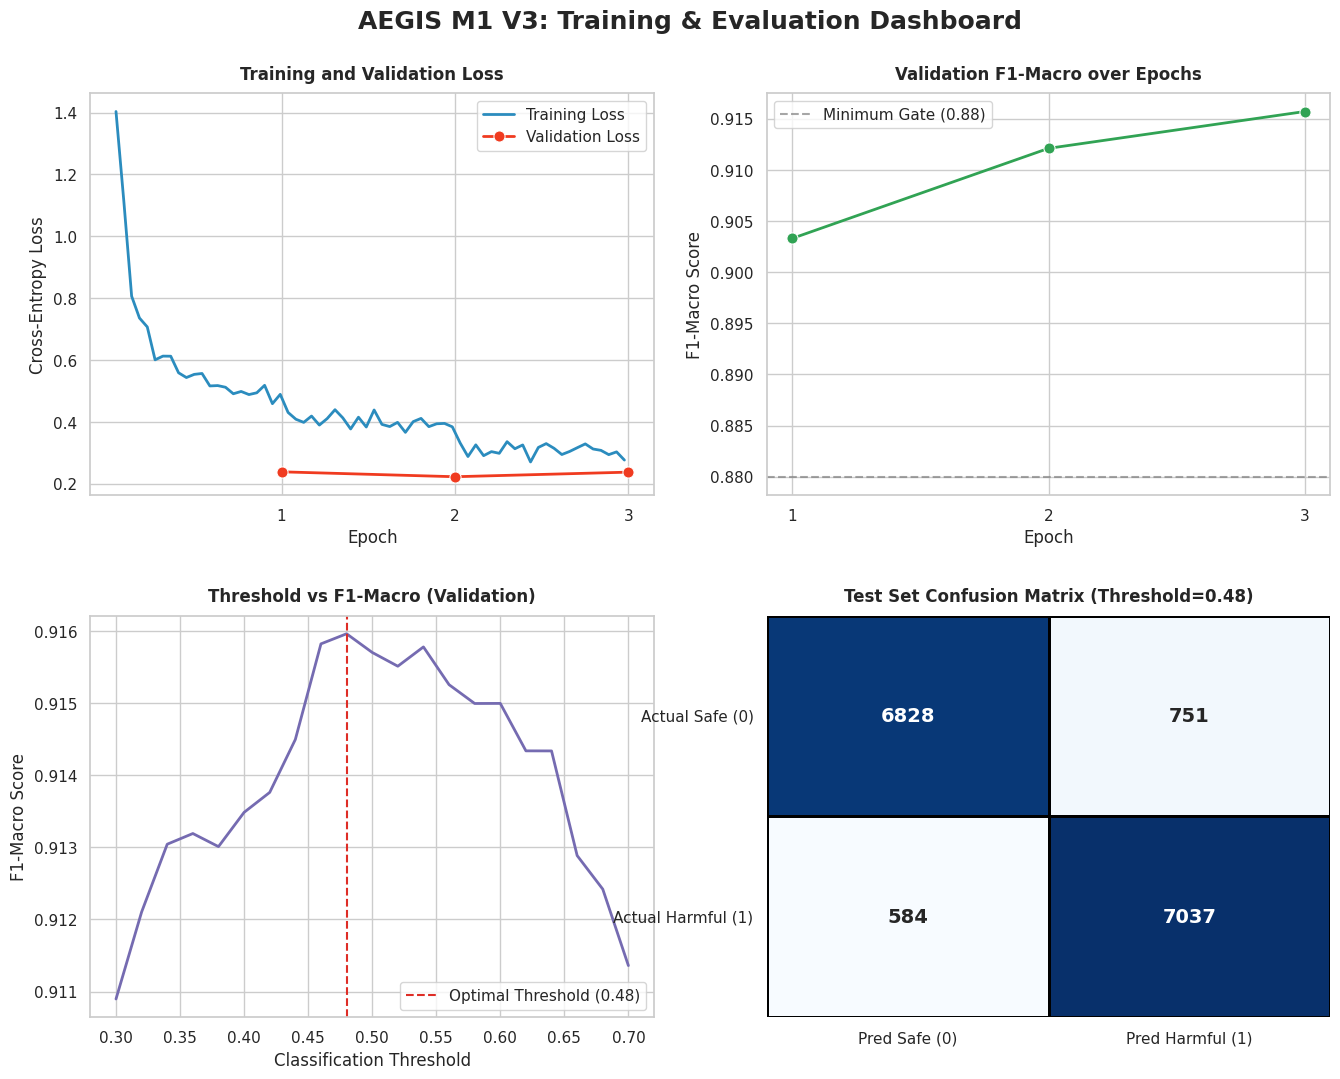

✅ Dashboard saved successfully to: 
/content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3/plots/m1_training_dashboard.png


In [ ]:
# ============================================================
# CELL 9 — M1 Training Dashboard (2x2 Grid)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd

# Create plots directory inside the M1 model folder
PLOTS_DIR = MODELS / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

# --- Extract Training History ---
history = trainer.state.log_history
train_steps, train_loss = [], []
val_epochs, val_loss, val_f1 = [], [], []

for log in history:
    if "loss" in log and "epoch" in log:
        train_steps.append(log["epoch"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log and "epoch" in log:
        val_epochs.append(log["epoch"])
        val_loss.append(log["eval_loss"])
        val_f1.append(log["eval_f1_macro"])

# --- Create 2x2 Grid ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)
fig.suptitle("AEGIS M1 V3: Training & Evaluation Dashboard", fontsize=18, fontweight='bold', y=0.95)

# [Plot 1 - Top Left] Loss Curve
ax = axes[0, 0]
if train_loss:
    sns.lineplot(x=train_steps, y=train_loss, label='Training Loss', color='#2b8cbe', linewidth=2, ax=ax)
if val_loss:
    sns.lineplot(x=val_epochs, y=val_loss, label='Validation Loss', marker='o', color='#f03b20', markersize=8, linewidth=2, ax=ax)
ax.set_title("Training and Validation Loss", pad=10, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
if val_epochs:
    ax.set_xticks(range(1, len(val_epochs) + 1))

# [Plot 2 - Top Right] F1 Progression
ax = axes[0, 1]
if val_f1:
    sns.lineplot(x=val_epochs, y=val_f1, marker='o', color='#31a354', markersize=8, linewidth=2, ax=ax)
    ax.axhline(0.88, color='gray', linestyle='--', alpha=0.7, label='Minimum Gate (0.88)')
ax.set_title("Validation F1-Macro over Epochs", pad=10, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("F1-Macro Score")
if val_epochs:
    ax.set_xticks(range(1, len(val_epochs) + 1))
ax.legend()

# [Plot 3 - Bottom Left] Threshold Tuning
ax = axes[1, 0]
if 'results' in locals() and 'best_t' in locals():
    thresh_x = [r[0] for r in results]
    f1_y = [r[1] for r in results]
    sns.lineplot(x=thresh_x, y=f1_y, color='#756bb1', linewidth=2, ax=ax)
    ax.axvline(best_t, color='#de2d26', linestyle='--', label=f'Optimal Threshold ({best_t:.2f})')
    ax.set_title("Threshold vs F1-Macro (Validation)", pad=10, fontweight='bold')
    ax.set_xlabel("Classification Threshold")
    ax.set_ylabel("F1-Macro Score")
    ax.legend(loc='lower right')

# [Plot 4 - Bottom Right] Test Set Confusion Matrix
ax = axes[1, 1]
if 'test_labels' in locals() and 'final_preds' in locals():
    cm = confusion_matrix(test_labels, final_preds)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual Safe (0)', 'Actual Harmful (1)'],
        columns=['Pred Safe (0)', 'Pred Harmful (1)']
    )
    sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'},
                linewidths=1, linecolor='black', ax=ax)
    ax.set_title(f"Test Set Confusion Matrix (Threshold={best_t:.2f})", pad=10, fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Save combined dashboard
combined_path = PLOTS_DIR / "m1_training_dashboard.png"
plt.savefig(combined_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Dashboard saved successfully to: \n{combined_path}")


In [ ]:
# ============================================================
# CELL 8 — Save Model + Config + Threshold
# ============================================================
import json

print('Saving M1 V4 model to Drive...')
model.save_pretrained(str(MODELS))
tokenizer.save_pretrained(str(MODELS))
print(f'  ✅ Model saved     -> {MODELS}')

# Optimal threshold
threshold_path = MODELS / 'threshold.json'
with open(threshold_path, 'w') as f:
    json.dump({
        'optimal_threshold': float(best_t),
        'val_f1_macro':      float(best_f1),
        'val_f1_at_0.50':   float(f1_at_50),
    }, f, indent=2)
print(f'  ✅ Threshold saved -> {threshold_path}')

# AEGIS config
config = {
    'model_name':        MODEL_NAME,
    'version':           'v3',
    'task':              'M1_binary',
    'label2id':          LABEL2ID,
    'id2label':          ID2LABEL,
    'max_length':        MAX_LENGTH,
    'optimal_threshold': float(best_t),
    'val_f1_macro':      float(best_f1),
    'training_epochs':   3,
    'effective_batch':   32,
    'learning_rate':     2e-5,
    'label_smoothing':   0.0,
    'phase2_fix':        'label_smoothing=0.0 (was 0.1) — clean V3 labels need no softening',
    'corpus':            'm1_trainV3.csv ~70K rows (50K safe / 50K harmful)',
    'corpus_sources':    '11 safe sources — personachat, daily_dialog, kaggle-safe, '
                         'tweeteval-safe, davidson-safe, edos-safe, olid-NOT, '
                         'stormfront-noHate, hasoc-NOT, aegis-safe, synthetic',
    'notes':             'xlm-roberta-base, T4 GPU, Phase 2 of AEGIS remediation plan',
}
config_path = MODELS / 'aegis_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'  ✅ Config saved    -> {config_path}')

print(f'\nFiles in {MODELS}:')
for p in sorted(MODELS.iterdir()):
    print(f'  {p.name:<40} {p.stat().st_size/1e6:>7.1f} MB')

print(f'\n{"="*60}')
print('M1 V3 TRAINING COMPLETE')
print(f'{"="*60}')
print(f'  Model            : {MODEL_NAME}')
print(f'  Corpus           : V3 (clean slate, 50K/50K, 11 safe sources)')
print(f'  label_smoothing  : 0.0  [Phase 2 fix]')
print(f'  Val F1-macro     : {best_f1:.4f}  (threshold={best_t:.2f})')
print(f'  Saved to         : {MODELS}')
print(f'{"="*60}')
print('\n✅ M1 V3 done. Next: m2_sequential_finetuningV3.ipynb')


Saving M1 V3 model to Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model saved     -> /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3
  ✅ Threshold saved -> /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3/threshold.json
  ✅ Config saved    -> /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3/aegis_config.json

Files in /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3:
  aegis_config.json                            0.0 MB
  checkpoints                                  0.0 MB
  config.json                                  0.0 MB
  model.safetensors                         1112.2 MB
  plots                                        0.0 MB
  threshold.json                               0.0 MB
  tokenizer.json                              16.8 MB
  tokenizer_config.json                        0.0 MB

M1 V3 TRAINING COMPLETE
  Model            : xlm-roberta-base
  Corpus           : V3 (clean slate, 50K/50K, 11 safe sources)
  label_smoothing  : 0.0  [Phase 2 fix]
  Val F1-macro     : 0.9160  (threshold=0.48)
  Saved to         : /